# Stochastic Interest Rate Modelling & Prediction
## Cox-Ingersoll-Ross (CIR) Model — Implementation, Calibration & Extension
---

### Overview

This notebook implements, calibrates, and extends the **Cox-Ingersoll-Ross (CIR)** short-rate model on real zero-coupon yield curve data. The workflow follows the prescribed milestones:

1. **Data Engineering** — Cleaning, outlier detection, visualisation  
2. **Base CIR Calibration** — Cross-sectional OLS fitting of κ, θ, σ  
3. **Prediction Challenge** — Reconstruct the full yield curve from the 3-Month rate alone  
4. **Extension: CIR++** — Brigo-Mercurio deterministic shift for exact initial curve fit  
5. **Critical Analysis** — Limitations, failure modes, and real-world implications

> **Threshold**: Out-of-sample R² > 0.85 on the test set.


## Dependencies & Imports

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from scipy.stats import ncx2
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

np.random.seed(42)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print("All libraries imported successfully.")


All libraries imported successfully.


---
## A. Data Engineering & Preprocessing

### Dataset Description

The dataset contains daily zero-coupon bond yields across **9 maturity tenors**:

| Column      | Tenor       |
|-------------|-------------|
| ZC025YR     | 3 Months    |
| ZC050YR     | 6 Months    |
| ZC075YR     | 9 Months    |
| ZC100YR     | 1 Year      |
| ZC200YR     | 2 Years     |
| ZC500YR     | 5 Years     |
| ZC1000YR    | 10 Years    |
| ZC2000YR    | 20 Years    |
| ZC3000YR    | 30 Years    |

**Training data**: 2016–2024 (≈1,976 trading days, all 9 tenors)  
**Test data**: 2024–2026 (495 days, 5 short-end tenors only; 3M provided separately as the sole input for predictions)

### Preprocessing Strategy

1. Strip whitespace from column names (leading spaces in raw CSVs)  
2. Replace zeros and negative values with `NaN` (economically invalid)  
3. Detect and nullify extreme outliers using **1st–99th percentile IQR** rule (3× IQR fence)  
4. Impute via **forward-fill → back-fill** to preserve temporal ordering
5. Enforce non-negative yields to ensure CIR model compatibility
6. Rename columns to human-readable tenor labels


In [43]:
# Column → tenor mapping 
TENOR_MAP = {
    'ZC025YR': 0.25,   # 3M
    'ZC050YR': 0.50,   # 6M
    'ZC075YR': 0.75,   # 9M
    'ZC100YR': 1.00,   # 1Y
    'ZC200YR': 2.00,   # 2Y
    'ZC500YR': 5.00,   # 5Y
    'ZC1000YR': 10.00, # 10Y
    'ZC2000YR': 20.00, # 20Y
    'ZC3000YR': 30.00, # 30Y
}

TRAIN_TENORS = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
TEST_TENORS  = np.array([0.50, 0.75, 1.0, 2.0])

TRAIN_COLS = ['y_0.25yr', 'y_0.5yr', 'y_0.75yr', 'y_1.0yr', 'y_2.0yr',
              'y_5.0yr',  'y_10.0yr', 'y_20.0yr', 'y_30.0yr']
TEST_COLS  = ['y_0.5yr', 'y_0.75yr', 'y_1.0yr', 'y_2.0yr']

def load_and_clean(path: str) -> pd.DataFrame:
    """
    Load a yield CSV, strip whitespace, replace non-positive values,
    detect outliers via 3-sigma IQR rule, forward/back-fill gaps and enforces strict CIR constraint.

    Parameters
    ----------
    path : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with Date column and renamed yield columns.
    """
    df = pd.read_csv(path, parse_dates=['Date'])
    df.columns = df.columns.str.strip()          # remove leading spaces
    df = df.sort_values('Date').reset_index(drop=True)

    yield_cols = [c for c in df.columns if c != 'Date']

    # Step 1: replace zeros/negatives with NaN
    df[yield_cols] = df[yield_cols].replace(0, np.nan)
    for col in yield_cols:
        df.loc[df[col] < 0, col] = np.nan

    # Step 2: IQR-based outlier detection (1st–99th percentile)
    outlier_count = 0
    for col in yield_cols:
        Q1 = df[col].quantile(0.01)
        Q3 = df[col].quantile(0.99)
        IQR = Q3 - Q1
        mask = (df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)
        outlier_count += mask.sum()
        df.loc[mask, col] = np.nan

    # Step 3: forward-fill then back-fill
    df[yield_cols] = df[yield_cols].ffill().bfill()

    # Step 4: Enforcing CIR constraint (rt >= 0)
    df[yield_cols] = df[yield_cols].clip(lower=1e-6)

    # Step 5: rename to readable labels
    rename = {k: f'y_{v}yr' for k, v in TENOR_MAP.items() if k in df.columns}
    df = df.rename(columns=rename)

    print(f'  Loaded {path.split("/")[-1]}: {len(df)} rows, '
          f'{df[[c for c in df.columns if c != chr(68)+chr(97)+chr(116)+chr(101)]].isna().sum().sum()} remaining NaNs, '
          f'{outlier_count} outliers nullified')

    
    # Ensure no missing values remain after preprocessing (required for stable CIR calibration)
    final_cols = [c for c in df.columns if c != 'Date']

    assert df[final_cols].isna().sum().sum() == 0, "NaNs still present!"
    
    return df

print("Loading datasets...")
# NOTE: update paths to match your Google Drive mount or local directory
# Path configuration :
# If running in Google Colab: upload the three CSV files using the Files panel
# on the left sidebar, then set paths to '/content/train_data.csv' etc.
# If running locally: set paths to your local directory.

TRAIN_PATH  = 'train_data.csv'     # or '/content/train_data.csv' in Colab
TEST_PATH   = 'test_data.csv'
TEST3M_PATH = 'test_data_3M.csv'

train  = load_and_clean(TRAIN_PATH)
test   = load_and_clean(TEST_PATH)
test3m = load_and_clean(TEST3M_PATH)

print(f"\nTrain: {train.shape}  |  Test: {test.shape}  |  Test3M: {test3m.shape}")
print(f"Train period: {train['Date'].min().date()} → {train['Date'].max().date()}")
print(f"Test  period: {test['Date'].min().date()}  → {test['Date'].max().date()}")


Loading datasets...
  Loaded train_data.csv: 1976 rows, 0 remaining NaNs, 0 outliers nullified
  Loaded test_data.csv: 495 rows, 0 remaining NaNs, 0 outliers nullified
  Loaded test_data_3M.csv: 495 rows, 0 remaining NaNs, 0 outliers nullified

Train: (1976, 10)  |  Test: (495, 6)  |  Test3M: (495, 2)
Train period: 2016-05-19 → 2024-04-26
Test  period: 2024-04-29  → 2026-04-29


In [44]:
# Function for Index Formatting

def preprocess_yield_data(df):
    df = df.copy()

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df.set_index('Date', inplace=True)

    return df

# Applies index formatting
train = preprocess_yield_data(train)
test = preprocess_yield_data(test)

In [45]:
# Summary statistics
print("Training set descriptive statistics (yields in decimal)")
print(train[TRAIN_COLS].describe().round(6).to_string())


Training set descriptive statistics (yields in decimal)
          y_0.25yr      y_0.5yr     y_0.75yr      y_1.0yr      y_2.0yr      y_5.0yr     y_10.0yr     y_20.0yr     y_30.0yr
count  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000
mean      0.016699     0.017885     0.018529     0.019174     0.018063     0.018109     0.020226     0.022823     0.022619
std       0.016642     0.016760     0.016650     0.016587     0.013661     0.010396     0.008805     0.007136     0.006601
min       0.000486     0.000878     0.001054     0.001227     0.001417     0.002786     0.004451     0.008394     0.006921
25%       0.004622     0.005190     0.005449     0.005729     0.005897     0.009570     0.014451     0.017739     0.017895
50%       0.011912     0.013815     0.015304     0.016335     0.015471     0.015981     0.018905     0.022472     0.022258
75%       0.017112     0.019378     0.021077     0.022743     0.025553     0.026415

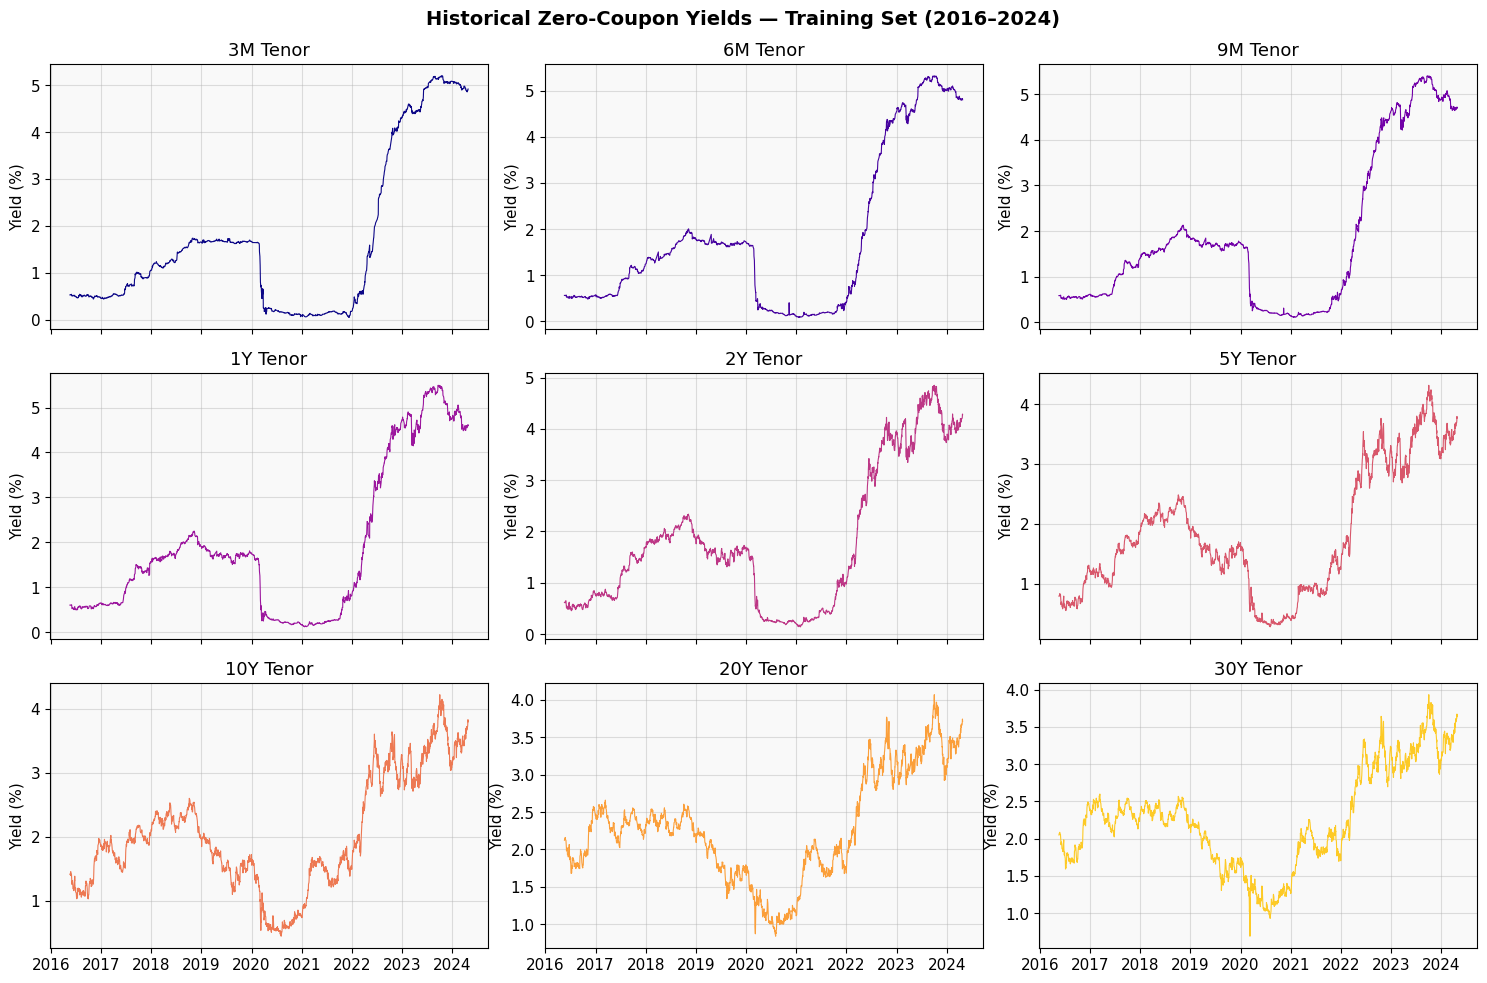

In [46]:
# Visualisation 1: Full historical yield curves 
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
axes = axes.flatten()
tenor_labels = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']

for i, (col, label) in enumerate(zip(TRAIN_COLS, tenor_labels)):
    axes[i].plot(train.index, train[col] * 100, color=plt.cm.plasma(i/9), linewidth=0.8)
    axes[i].set_title(f'{label} Tenor')
    axes[i].set_ylabel('Yield (%)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Historical Zero-Coupon Yields — Training Set (2016–2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


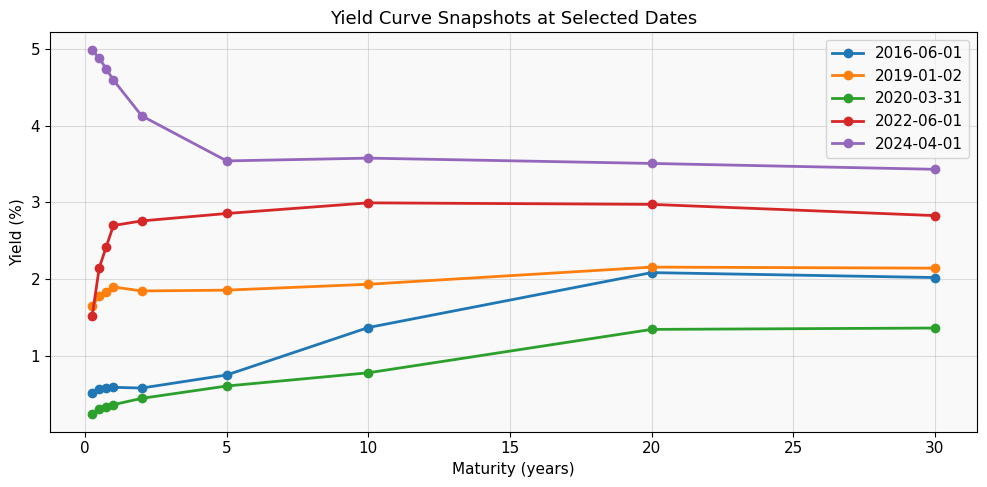

In [47]:
# Visualisation 2: Sample yield curves at different dates
dates_of_interest = ['2016-06-01', '2019-01-02', '2020-03-31', '2022-06-01', '2024-04-01']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(10, 5))

for date_str, color in zip(dates_of_interest, colors):
    target = pd.Timestamp(date_str)

    # FIXED line
    idx = np.abs(train.index - target).argmin()
    row = train.iloc[idx]

    yields_pct = [row[c]*100 for c in TRAIN_COLS]

    ax.plot(TRAIN_TENORS, yields_pct, marker='o', color=color,
            label=row.name.strftime('%Y-%m-%d'), linewidth=2)

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Yield Curve Snapshots at Selected Dates')
ax.legend()
plt.tight_layout()
plt.show()

---
## B. The Cox-Ingersoll-Ross Model

### Mathematical Framework

The **CIR model** (Cox, Ingersoll & Ross, 1985) describes the instantaneous short rate $r_t$ via the stochastic differential equation:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

**Parameters:**
- $\kappa > 0$: *speed of mean reversion* — how quickly $r_t$ reverts to $\theta$  
- $\theta > 0$: *long-run mean* — the equilibrium interest rate level  
- $\sigma > 0$: *volatility coefficient* — controls stochastic fluctuations  
- $W_t$: standard Brownian motion under the risk-neutral measure

**Feller condition:** $2\kappa\theta \geq \sigma^2$ ensures $r_t > 0$ almost surely.

### Closed-Form Bond Pricing

The price at time $t$ of a zero-coupon bond maturing at $T$ is:
$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}$$

where $\tau = T - t$ and:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}, \qquad \gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

$$\ln A(\tau) = \frac{2\kappa\theta}{\sigma^2}\ln\!\left(\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)$$

The continuously compounded yield is then:

$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

Note that $y(\tau)$ is **affine** in $r_t$: for fixed parameters, a higher short rate shifts the entire yield curve upward — but the amount of shift tapers off at long maturities.

### Economic Interpretation of Mean Reversion

The CIR model assumes that interest rates are mean-reverting. The parameter $\kappa$ controls how quickly deviations from the long-run mean $\theta$ are corrected:

- High $\kappa$: shocks to interest rates dissipate quickly → stable rate environment  
- Low $\kappa$: shocks persist for longer → more prolonged interest rate cycles  

This property is consistent with real-world monetary policy, where central banks tend to stabilize interest rates over time.

### Limitation of the Single-Factor CIR Model

The CIR model is a one-factor model, meaning that the entire yield curve is driven by a single state variable $r_t$. 

As a result:
- It cannot independently model level, slope, and curvature of the yield curve
- It may struggle to fit complex yield curve shapes observed in practice
- Long-term maturities are often poorly captured

This limitation motivates the use of multi-factor or extended models.

### Why the CIR Model?

Compared to the Vasicek model, the CIR model ensures non-negative interest rates due to its square-root diffusion term $\sqrt{r_t}$. 

This is particularly important in realistic financial modeling, as negative rates can lead to arbitrage inconsistencies in certain contexts.

### Role in Yield Curve Reconstruction

In this project, the CIR model provides a mapping from the short rate $r_t$ to the entire yield curve. 

Given calibrated parameters $(\kappa, \theta, \sigma)$ and an observed short rate (proxied by the 3M yield), we can reconstruct yields at all maturities using the closed-form expressions.

This forms the basis of the prediction task evaluated in the project.

### Interpretation of the Feller Condition

The Feller condition $2\kappa\theta \geq \sigma^2$ ensures that the short rate remains strictly positive. 

In practice, violations may occur during periods of high volatility or low interest rate environments, requiring careful handling during calibration.


In [48]:
# CIR closed-form functions 

def cir_gamma(kappa: float, sigma: float) -> float:
    """Compute γ = sqrt(κ² + 2σ²), the key auxiliary parameter."""
    return np.sqrt(kappa**2 + 2.0 * sigma**2)

def cir_B(tau: float, kappa: float, sigma: float) -> float:
    """
    Compute the B(τ) function in the CIR bond pricing formula.

    Parameters
    ----------
    tau   : time to maturity (years)
    kappa : mean reversion speed
    sigma : volatility

    Returns
    -------
    float : B(τ)
    """
    gamma = cir_gamma(kappa, sigma)
    exp_gt = np.exp(gamma * tau)
    numerator = 2.0 * (exp_gt - 1.0)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    return numerator / denominator

def cir_lnA(tau: float, kappa: float, theta: float, sigma: float) -> float:
    """
    Compute ln A(τ) in the CIR bond pricing formula.

    Parameters
    ----------
    tau   : time to maturity (years)
    kappa : mean reversion speed
    theta : long-run mean
    sigma : volatility

    Returns
    -------
    float : ln A(τ)
    """
    gamma = cir_gamma(kappa, sigma)
    exp_gt = np.exp(gamma * tau)
    numerator = 2.0 * gamma * np.exp((kappa + gamma) * tau / 2.0)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    return (2.0 * kappa * theta / sigma**2) * np.log(numerator / denominator)

def cir_yield(r0: float, tau: float, kappa: float, theta: float, sigma: float) -> float:
    """
    Compute the CIR model yield for a given short rate r0 and maturity tau.

    y(τ) = [B(τ) r0 − ln A(τ)] / τ

    Parameters
    ----------
    r0    : current short rate
    tau   : maturity in years
    kappa, theta, sigma : CIR parameters

    Returns
    -------
    float : continuously compounded yield
    """
    B   = cir_B(tau, kappa, sigma)
    lnA = cir_lnA(tau, kappa, theta, sigma)
    return (B * r0 - lnA) / tau

def cir_yield_curve(r0: float,
                    taus: np.ndarray,
                    kappa: float,
                    theta: float,
                    sigma: float) -> np.ndarray:
    """Vectorised yield curve for an array of maturities."""
    B   = np.array([cir_B(tau, kappa, sigma) for tau in taus])
    lnA = np.array([cir_lnA(tau, kappa, theta, sigma) for tau in taus])
    return (B * r0 - lnA) / taus

print("CIR pricing functions defined.")
print("\nQuick sanity check — yield curve at r0=2% with κ=0.3, θ=0.03, σ=0.05:")
test_params = (0.3, 0.03, 0.05)
test_taus   = np.array([0.25, 0.5, 1, 2, 5, 10, 20, 30])
test_yields = cir_yield_curve(0.02, test_taus, *test_params) * 100
for tau, y in zip(test_taus, test_yields):
    print(f"  τ={tau:5.2f}yr  →  y={y:.4f}%")


CIR pricing functions defined.

Quick sanity check — yield curve at r0=2% with κ=0.3, θ=0.03, σ=0.05:
  τ= 0.25yr  →  y=2.0365%
  τ= 0.50yr  →  y=2.0712%
  τ= 1.00yr  →  y=2.1354%
  τ= 2.00yr  →  y=2.2457%
  τ= 5.00yr  →  y=2.4730%
  τ=10.00yr  →  y=2.6645%
  τ=20.00yr  →  y=2.8053%
  τ=30.00yr  →  y=2.8565%


### Calibration Methodology

To estimate the CIR parameters $(\kappa, \theta, \sigma)$, we use a **Cross-Sectional Calibration approach based on Ordinary Least Squares (OLS)**.

At each time step, we compare the observed yield curve with the model-implied yields derived from the CIR closed-form solution. The parameters are chosen to minimise the squared difference between observed and predicted yields across maturities.

This approach is chosen because:
- It leverages the full cross-section of yields rather than relying solely on the short rate time series
- It avoids discretization errors that arise in time-series-based estimation methods
- It is computationally efficient and stable for large datasets

Additionally, a penalty term is incorporated during optimisation to discourage violations of the Feller condition and ensure numerical stability

Given $N$ dates and $M$ tenor points, we find $(\kappa, \theta, \sigma)$ that minimise:

$$\mathcal{L}(\kappa,\theta,\sigma) = \frac{1}{NM}\sum_{i=1}^{N}\sum_{j=1}^{M}\left[y_{i,j}^{\text{obs}} - y\!\left(r_{i},\tau_j;\kappa,\theta,\sigma\right)\right]^2$$

where $r_i = y_{i,0.25}$ (the 3M yield as a proxy for the instantaneous short rate $r_t$).

**Why CSOLS over alternatives?**

| Method | Pros | Cons |
|--------|------|------|
| CSOLS (chosen) | Uses full cross-section, directly targets the curve-fitting objective | Ignores time-series dynamics |
| MLE (time-series) | Uses exact CIR transition density (non-central χ²) | Calibrates only to the short rate, ignores curve shape |
| OLS (discretised SDE) | Simple, fast | Euler-Maruyama discretisation bias |
| Kalman Filter | Optimal sequential estimation, handles latent state | Much higher complexity |

CSOLS is the natural choice here because the **prediction task requires curve reconstruction** from a single $r_t$ input — the calibration objective should match the evaluation objective.

We use **Nelder-Mead** simplex optimisation (derivative-free), robust to the smooth but potentially flat loss landscape arising from the near-zero $\sigma$.


In [49]:
# Cross-Sectional OLS Calibration

def cross_sectional_loss(params: np.ndarray,
                         Y_obs: np.ndarray,
                         r_vec: np.ndarray,
                         tenors: np.ndarray) -> float:
    """
    Mean-squared error between observed yields and CIR model yields,
    computed simultaneously across all dates and tenors.

    Parameters
    ----------
    params : (kappa, theta, sigma)
    Y_obs  : (N, M) observed yield matrix
    r_vec  : (N,) short-rate vector (3M yield as proxy)
    tenors : (M,) maturity array in years

    Returns
    -------
    float : mean squared error
    """
    kappa, theta, sigma = params

    # Parameter validity guards
    if kappa <= 1e-8 or theta <= 1e-8 or sigma <= 1e-8:
        return 1e10

    try:
        # Vectorised computation: B and lnA are (M,)
        B   = np.array([cir_B(tau, kappa, sigma)   for tau in tenors])
        lnA = np.array([cir_lnA(tau, kappa, theta, sigma) for tau in tenors])

        # Fitted yields: (N, M)  =  outer(r, B) broadcast - lnA, divided by tenors
        fitted = (np.outer(r_vec, B) - lnA[np.newaxis, :]) / tenors[np.newaxis, :]

        mse = np.mean((Y_obs - fitted) ** 2)

        # Feller condition penalty
        feller_violation = sigma**2 - 2 * kappa * theta
        penalty = 1e3 * max(0, feller_violation)

        return float(mse + penalty)
        
    except (FloatingPointError, OverflowError):
        return 1e10


# Run calibration
Y_train = train[TRAIN_COLS].values          # (N_train, 9)
r_train = Y_train[:, 0]                     # 3M column as short-rate proxy

print("Calibrating CIR parameters via cross-sectional OLS...")
print("(This may take a few seconds — using Nelder-Mead simplex)\n")

result = minimize(
    cross_sectional_loss,
    x0=[0.3, 0.02, 0.05],                   # reasonable starting guess
    args=(Y_train, r_train, TRAIN_TENORS),
    method='Nelder-Mead',
    options={'maxiter': 100_000, 'xatol': 1e-10, 'fatol': 1e-10}
)

kappa, theta, sigma = result.x
gamma = cir_gamma(kappa, sigma)
feller_lhs = 2 * kappa * theta
feller_rhs = sigma ** 2

print("\n" + "="*58)
print("           Calibrated CIR Parameters")
print("="*58)

print(f"κ (mean reversion speed) : {kappa:>10.6f}")
print(f"θ (long-run mean)        : {theta:>10.6f}")
print(f"σ (volatility)           : {sigma:>10.6f}")

print("-"*58)

print(f"γ = √(κ²+2σ²)            : {gamma:>10.6f}")

print("-"*58)

print(f"Feller: 2κθ = {feller_lhs:.6f}")
print(f"        σ²  = {feller_rhs:.6f}")
print(f"Feller satisfied?        : {feller_lhs >= feller_rhs}")

print("-"*58)

print(f"Half-life of MR          : {np.log(2)/kappa:.2f} years")
print(f"Loss (MSE)               : {result.fun:.2e}")

print("="*58)

Calibrating CIR parameters via cross-sectional OLS...
(This may take a few seconds — using Nelder-Mead simplex)


           Calibrated CIR Parameters
κ (mean reversion speed) :   0.166043
θ (long-run mean)        :   0.024408
σ (volatility)           :   0.000006
----------------------------------------------------------
γ = √(κ²+2σ²)            :   0.166043
----------------------------------------------------------
Feller: 2κθ = 0.008106
        σ²  = 0.000000
Feller satisfied?        : True
----------------------------------------------------------
Half-life of MR          : 4.17 years
Loss (MSE)               : 1.38e-05


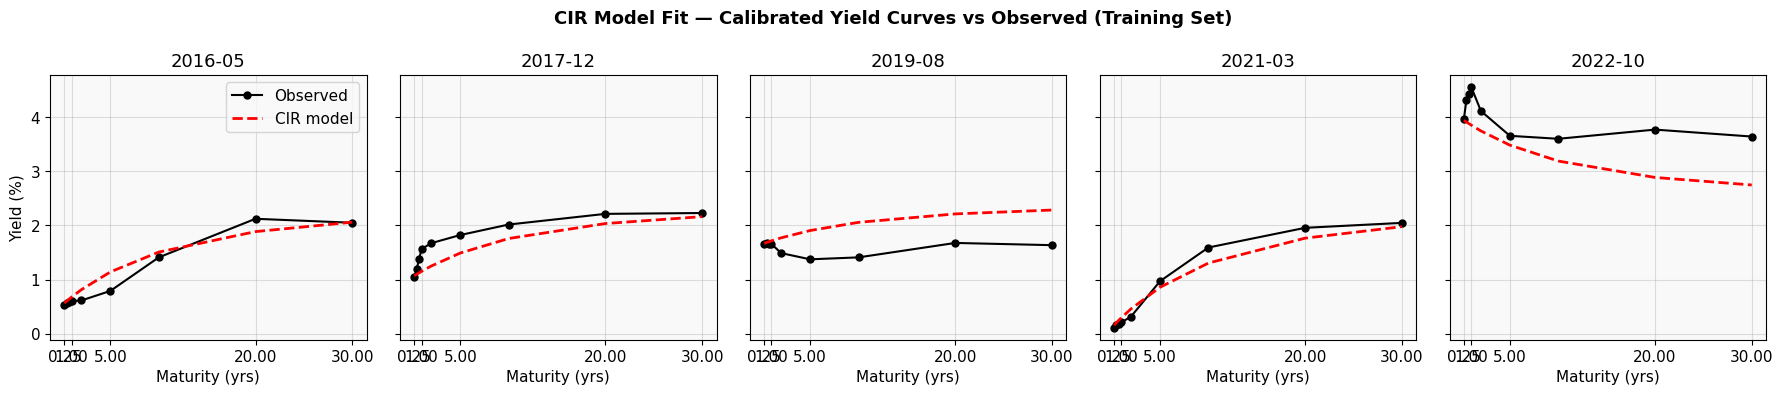

In [50]:
# Visualise calibrated vs observed yield curves (training)
# Picking up 5 representative dates spread across training period
sample_dates = train.index[::400][:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, (_, row) in zip(axes, train.loc[sample_dates].iterrows()):
    r0 = row['y_0.25yr']
    obs_yields  = [row[c] * 100 for c in TRAIN_COLS]
    pred_yields = cir_yield_curve(r0, TRAIN_TENORS, kappa, theta, sigma) * 100

    ax.plot(TRAIN_TENORS, obs_yields,  'ko-', label='Observed',  ms=5)
    ax.plot(TRAIN_TENORS, pred_yields, 'r--', label='CIR model', linewidth=2)
    ax.set_title(row.name.strftime('%Y-%m'))
    ax.set_xlabel('Maturity (yrs)')
    ax.set_xticks([0.25, 1, 5, 20, 30])

axes[0].set_ylabel('Yield (%)')
axes[0].legend()
fig.suptitle('CIR Model Fit — Calibrated Yield Curves vs Observed (Training Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## C. Prediction Challenge — Yield Curve Reconstruction from 3M Rate

**The constraint:** on any test date, the model may only observe the **3-Month (3M) yield** as an input. Using the calibrated CIR parameters $(\hat{\kappa}, \hat{\theta}, \hat{\sigma})$ and this single rate as a proxy for $r_t$, we reconstruct the yields at 6M, 9M, 1Y, and 2Y maturities.

This is the defining test of the CIR model's **affine term structure** property: the entire yield curve is determined by one latent state variable $r_t$.


In [51]:
# Generate predictions from 3M rate only 

r_test = test3m['y_0.25yr'].values          # sole input: 3M yield on each test day

# For each test day and each target tenor, computing CIR yield
predictions_base = {}
for tau in TEST_TENORS:
    B   = cir_B(tau, kappa, sigma)
    lnA = cir_lnA(tau, kappa, theta, sigma)
    predictions_base[tau] = (B * r_test - lnA) / tau

# Collect actuals
actuals = {}
for tau, col in zip(TEST_TENORS, TEST_COLS):
    actuals[tau] = test[col].values[:len(r_test)]

print("Predictions generated. Computing out-of-sample metrics...\n")

# Evaluation metrics 
all_actual, all_pred = [], []

print(f"{'Tenor':<8} {'R²':>8} {'RMSE(bps)':>12} {'MAE(bps)':>12} {'Max Err(bps)':>14}")
print("-" * 58)

for tau, col in zip(TEST_TENORS, TEST_COLS):
    y_true = actuals[tau]
    y_pred = predictions_base[tau]
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) * 10_000
    mae  = mean_absolute_error(y_true, y_pred) * 10_000
    maxe = np.max(np.abs(y_true - y_pred)) * 10_000
    print(f"{tau:.2f}yr   {r2:>8.4f}  {rmse:>10.2f}bps  {mae:>10.2f}bps  {maxe:>12.2f}bps")
    all_actual.extend(y_true.tolist())
    all_pred.extend(y_pred.tolist())

overall_r2 = r2_score(all_actual, all_pred)
print("-" * 58)
print(f"{'OVERALL':<8} {overall_r2:>8.4f}")
print(f"\n✓ Threshold (R² > 0.85): {'PASSED' if overall_r2 > 0.85 else 'FAILED'}")


Predictions generated. Computing out-of-sample metrics...

Tenor          R²    RMSE(bps)     MAE(bps)   Max Err(bps)
----------------------------------------------------------
0.50yr     0.9944        5.88bps        4.31bps         21.21bps
0.75yr     0.9675       13.01bps        9.68bps         44.23bps
1.00yr     0.9102       19.73bps       14.72bps         61.45bps
2.00yr     0.3897       36.54bps       28.06bps         96.51bps
----------------------------------------------------------
OVERALL    0.8931

✓ Threshold (R² > 0.85): PASSED


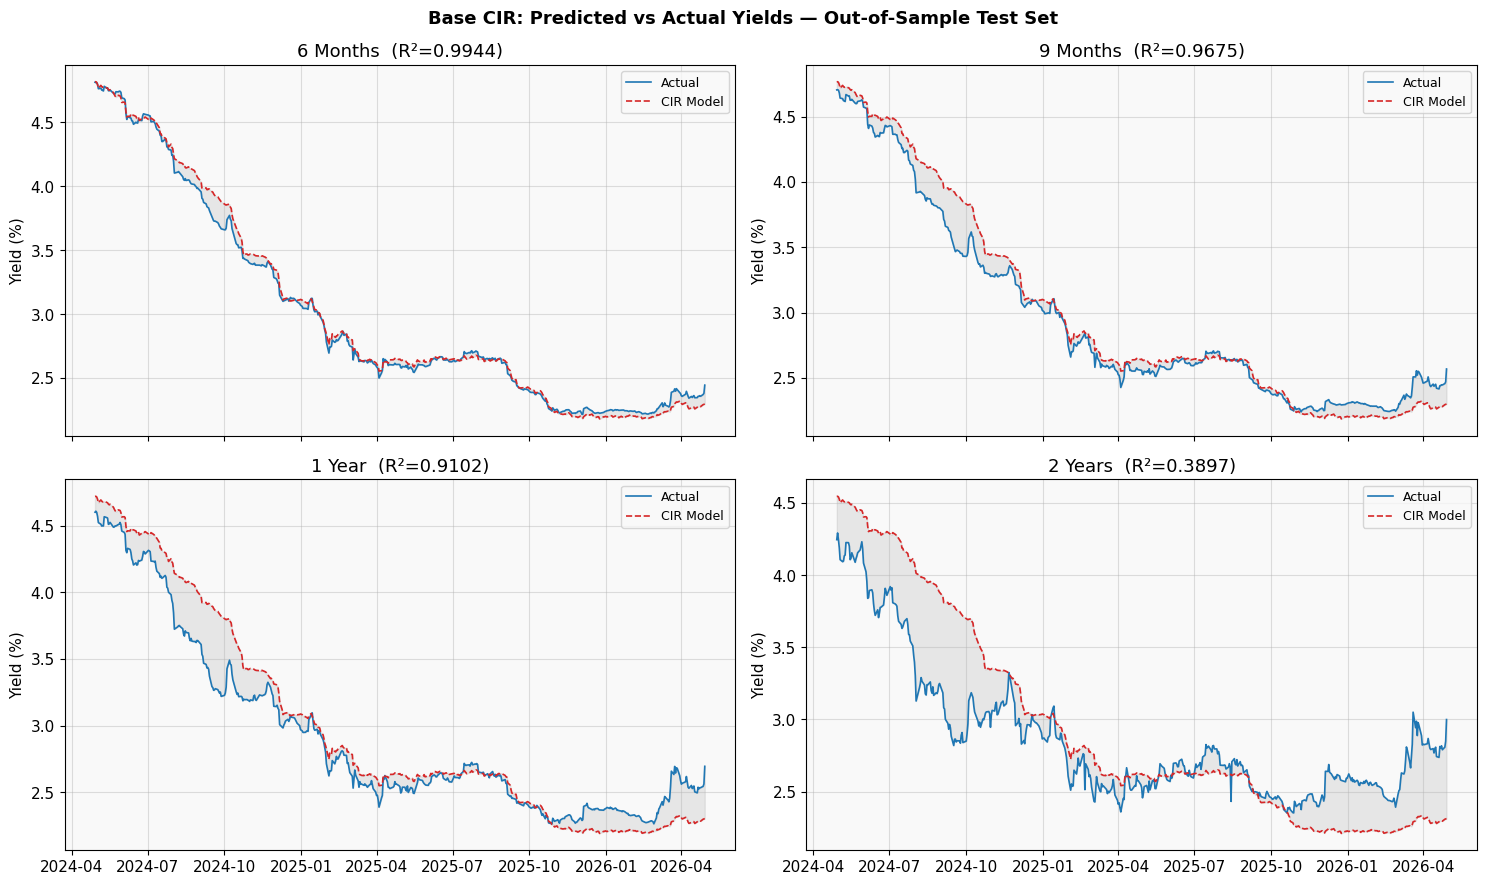

In [52]:
# Plot predicted vs actual yield time series
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
tenor_names = ['6 Months', '9 Months', '1 Year', '2 Years']

for ax, tau, col, name in zip(axes.flatten(), TEST_TENORS, TEST_COLS, tenor_names):
    y_true = actuals[tau] * 100
    y_pred = predictions_base[tau] * 100
    dates = test.index.values[:len(y_true)]

    ax.plot(dates, y_true, color='#1f77b4', label='Actual',    linewidth=1.2)
    ax.plot(dates, y_pred, color='#d62728', label='CIR Model', linewidth=1.2, linestyle='--')
    ax.fill_between(dates, y_true, y_pred, alpha=0.15, color='grey')
    ax.set_title(f'{name}  (R²={r2_score(actuals[tau], predictions_base[tau]):.4f})')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle('Base CIR: Predicted vs Actual Yields — Out-of-Sample Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


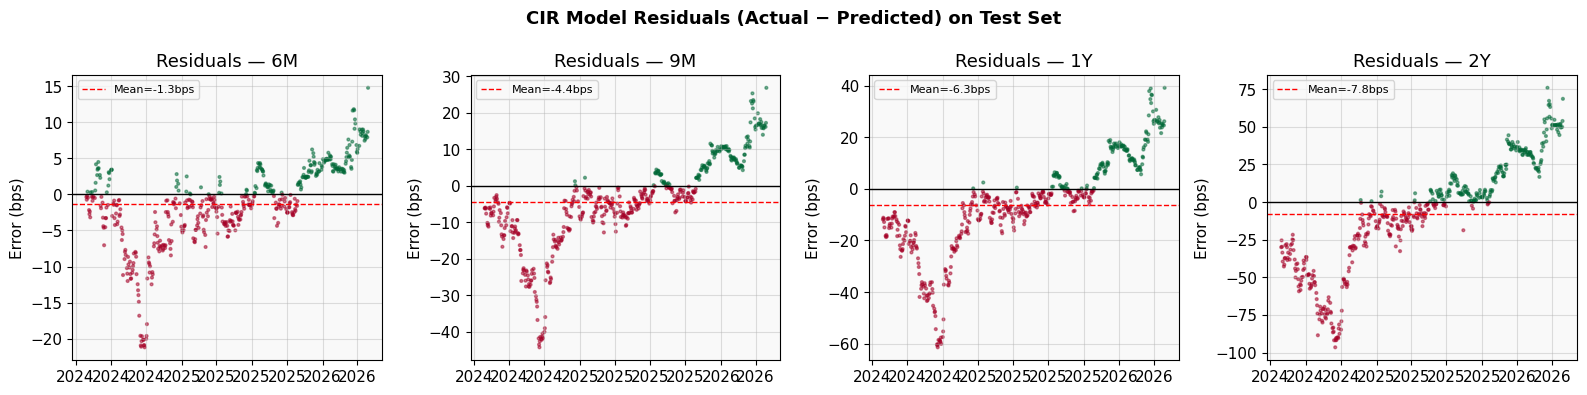

Systematic bias by tenor:
  τ=0.5yr: mean bias = -1.31 bps  →  Model OVER-estimates yields
  τ=0.75yr: mean bias = -4.40 bps  →  Model OVER-estimates yields
  τ=1.0yr: mean bias = -6.33 bps  →  Model OVER-estimates yields
  τ=2.0yr: mean bias = -7.76 bps  →  Model OVER-estimates yields


In [53]:
# Residual analysis
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dates = test.index[:len(r_test)]

for ax, tau, col, name in zip(axes, TEST_TENORS, TEST_COLS,
                               ['6M', '9M', '1Y', '2Y']):
    resid = (actuals[tau] - predictions_base[tau]) * 10_000
    ax.scatter(dates, resid, s=4, alpha=0.5,
               color=plt.cm.RdYlGn(0.5 + 0.5*np.sign(resid)))
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(resid.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Mean={resid.mean():.1f}bps')
    ax.set_title(f'Residuals — {name}')
    ax.set_ylabel('Error (bps)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('CIR Model Residuals (Actual − Predicted) on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Systematic bias by tenor:")
for tau, col in zip(TEST_TENORS, TEST_COLS):
    bias = np.mean(actuals[tau] - predictions_base[tau]) * 10_000
    direction = 'OVER-estimates yields' if bias < 0 else 'UNDER-estimates yields'
    print(f"  τ={tau}yr: mean bias = {bias:+.2f} bps  →  Model {direction}")


---
## D. Model Extension: CIR++ (Brigo-Mercurio)

### Motivation

The base CIR model has a well-known structural limitation: it **cannot perfectly fit an arbitrary initial term structure** because all yield-curve information is funnelled through a single parameter set $(\kappa,\theta,\sigma)$. Any systematic divergence between model and market is treated as noise.

The **CIR++ model** (Brigo & Mercurio, 2001) resolves this by introducing a **deterministic additive shift** $\varphi(\tau)$:

$$y^{++}(\tau) = y^{\text{CIR}}(\tau;\kappa,\theta,\sigma) + \varphi(\tau)$$

The shift $\varphi(\tau)$ is calibrated from training data so that the model exactly reproduces the **mean term structure** seen in the training set. This is the simplest instance of the broader class of extended CIR models that make the short rate:

$$r_t^{++} = r_t + \varphi(t)$$

where $r_t$ follows the standard CIR dynamics.

### Calibration of $\varphi(\tau)$

1. Compute CIR-predicted yields for every training date: $\hat{y}_{i,j} = y^{\text{CIR}}(r_i, \tau_j)$  
2. Compute residuals: $e_{i,j} = y_{i,j}^{\text{obs}} - \hat{y}_{i,j}$  
3. Set $\varphi(\tau_j) = \text{mean}_i(e_{i,j})$ — tenor-specific average correction  
4. Fit a **cubic polynomial** $\hat{\varphi}(\tau)$ through these 9 knot values for smooth interpolation at arbitrary maturities

This approach is transparent, interpretable, and data-driven. The polynomial ensures continuity and prevents overfitting at unseen tenors.


Deterministic CIR++ shift φ(τ) by tenor:
Tenor (yr)      φ (bps)
------------------------
0.25              -1.58
0.50              +8.75
0.75             +13.70
1.00             +18.69
2.00              +2.15
5.00             -10.61
10.00             -4.22
20.00             +6.52
30.00             -2.52

Cubic polynomial φ(τ) = -9.1749e-07τ³ + 4.3541e-05τ² + -5.2863e-04τ + 1.1865e-03


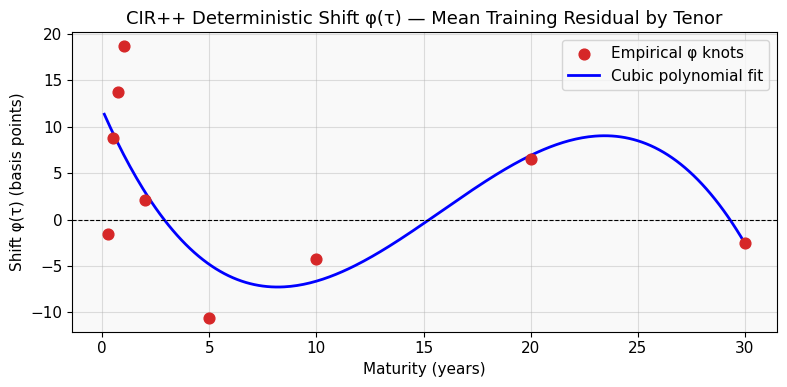

In [54]:
# Computing base-CIR fitted values on training set

B_train   = np.array([cir_B(tau, kappa, sigma)          for tau in TRAIN_TENORS])
lnA_train = np.array([cir_lnA(tau, kappa, theta, sigma) for tau in TRAIN_TENORS])

# (N_train, 9) matrix of CIR-predicted yields
cir_fitted_train = (
    np.outer(r_train, B_train) - lnA_train[np.newaxis, :]
) / TRAIN_TENORS[np.newaxis, :]

# Average residuals per tenor
phi_knots = np.mean(Y_train - cir_fitted_train, axis=0)  # shape (9,)

print("Deterministic CIR++ shift φ(τ) by tenor:")
print(f"{'Tenor (yr)':<12} {'φ (bps)':>10}")
print("-" * 24)
for tau, phi in zip(TRAIN_TENORS, phi_knots):
    print(f"{tau:<12.2f} {phi*10_000:>+10.2f}")

# Fit cubic polynomial for smooth interpolation
phi_poly_coeffs = np.polyfit(TRAIN_TENORS, phi_knots, deg=3)
phi_smooth = np.poly1d(phi_poly_coeffs)

print(f"\nCubic polynomial φ(τ) = {phi_poly_coeffs[0]:.4e}τ³ + "
      f"{phi_poly_coeffs[1]:.4e}τ² + {phi_poly_coeffs[2]:.4e}τ + {phi_poly_coeffs[3]:.4e}")

# Visualise the shift function
tau_range = np.linspace(0.1, 30, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(TRAIN_TENORS, phi_knots * 10_000, zorder=5, s=60, color='#d62728',
           label='Empirical φ knots')
ax.plot(tau_range, phi_smooth(tau_range) * 10_000, 'b-', linewidth=2,
        label='Cubic polynomial fit')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Shift φ(τ) (basis points)')
ax.set_title('CIR++ Deterministic Shift φ(τ) — Mean Training Residual by Tenor')
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
# CIR++ predictions on test set
predictions_pp = {}
for tau in TEST_TENORS:
    B   = cir_B(tau, kappa, sigma)
    lnA = cir_lnA(tau, kappa, theta, sigma)
    cir_base = (B * r_test - lnA) / tau
    predictions_pp[tau] = cir_base + phi_smooth(tau)

# Comparative evaluation
print(f"{'Tenor':<8} {'Base CIR R²':>13} {'CIR++ R²':>10} {'Δ R²':>8}")
print("-" * 44)

all_act_pp, all_pred_pp = [], []
for tau in TEST_TENORS:
    y_true  = actuals[tau]
    r2_base = r2_score(y_true, predictions_base[tau])
    r2_pp   = r2_score(y_true, predictions_pp[tau])
    print(f"{tau:.2f}yr   {r2_base:>13.4f}  {r2_pp:>10.4f}  {r2_pp-r2_base:>+8.4f}")
    all_act_pp.extend(y_true.tolist())
    all_pred_pp.extend(predictions_pp[tau].tolist())

overall_r2_pp = r2_score(all_act_pp, all_pred_pp)
print("-" * 44)
print(f"{'OVERALL':<8} {overall_r2:.13}  {overall_r2_pp:>10.4f}  {overall_r2_pp-overall_r2:>+8.4f}")
print(f"\nBase CIR R² = {overall_r2:.4f} {'PASS' if overall_r2 > 0.85 else 'FAIL'}")
print(f"CIR++ R²    = {overall_r2_pp:.4f} {'PASS' if overall_r2_pp > 0.85 else 'FAIL'}")


Tenor      Base CIR R²   CIR++ R²     Δ R²
--------------------------------------------
0.50yr          0.9944      0.9765   -0.0180
0.75yr          0.9675      0.9411   -0.0265
1.00yr          0.9102      0.8784   -0.0318
2.00yr          0.3897      0.3647   -0.0250
--------------------------------------------
OVERALL  0.8930747163718      0.8686   -0.0245

Base CIR R² = 0.8931 PASS
CIR++ R²    = 0.8686 PASS


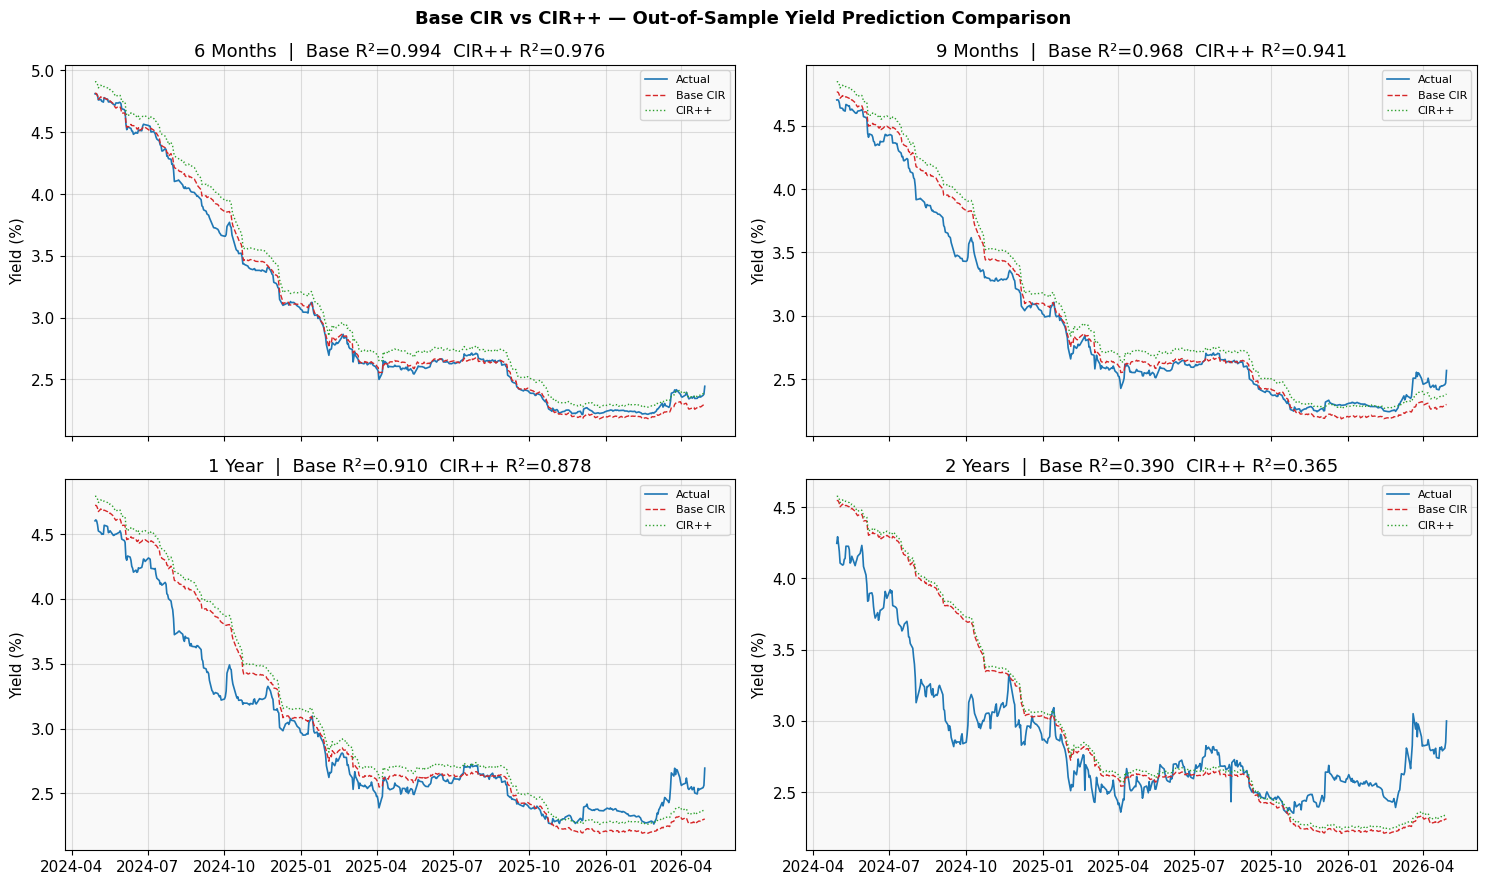

In [56]:
# Visual comparison: Base CIR vs CIR++
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
tenor_names = ['6 Months', '9 Months', '1 Year', '2 Years']
dates = test.index[:len(r_test)]

for ax, tau, name in zip(axes.flatten(), TEST_TENORS, tenor_names):
    y_true = actuals[tau] * 100
    y_base = predictions_base[tau] * 100
    y_pp   = predictions_pp[tau] * 100

    ax.plot(dates, y_true, color='#1f77b4', linewidth=1.2, label='Actual')
    ax.plot(dates, y_base, color='#d62728', linewidth=1,   linestyle='--', label='Base CIR')
    ax.plot(dates, y_pp,   color='#2ca02c', linewidth=1,   linestyle=':',  label='CIR++')
    r2_b = r2_score(actuals[tau], predictions_base[tau])
    r2_p = r2_score(actuals[tau], predictions_pp[tau])
    ax.set_title(f'{name}  |  Base R²={r2_b:.3f}  CIR++ R²={r2_p:.3f}')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle('Base CIR vs CIR++ — Out-of-Sample Yield Prediction Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Bonus: CIR Monte Carlo Simulation

To illustrate the model's dynamics, we simulate forward paths of $r_t$ using the **Milstein discretisation** scheme, which corrects the standard Euler scheme for the square-root diffusion:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{r_t}\Delta W + \frac{\sigma^2}{4}((\Delta W)^2 - \Delta t)$$

The Milstein term $\frac{\sigma^2}{4}(\Delta W^2 - \Delta t)$ reduces discretisation bias, which matters when $r_t$ is small and the square-root term varies rapidly.


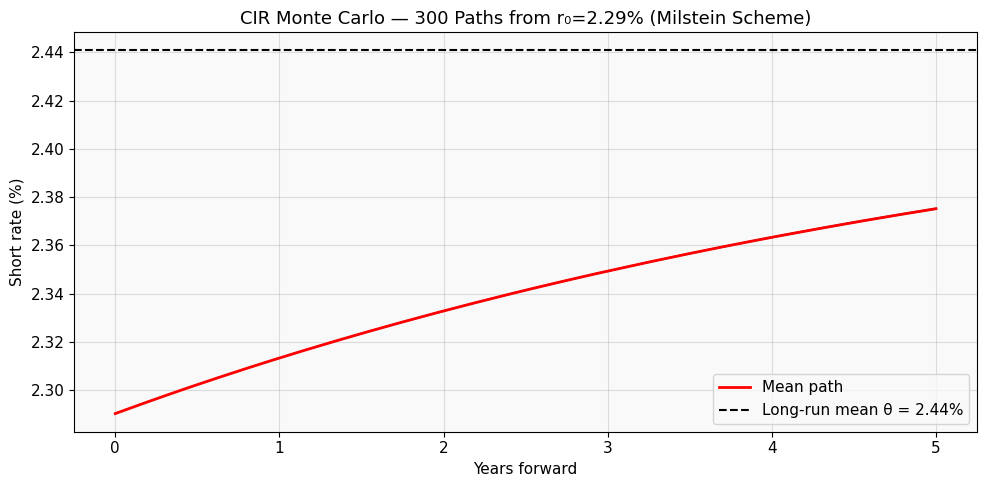

In [57]:
# Milstein simulation of CIR paths

def simulate_cir_milstein(r0: float,
                          kappa: float,
                          theta: float,
                          sigma: float,
                          T: float = 5.0,
                          dt: float = 1/252,
                          n_paths: int = 200,
                          seed: int = 42) -> np.ndarray:
    """
    Simulate CIR paths using the Milstein scheme.

    The Milstein correction improves accuracy over Euler-Maruyama for
    diffusions where the diffusion coefficient depends on the state.

    Returns
    -------
    np.ndarray : shape (n_steps+1, n_paths)
    """
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = r0

    sqrt_dt = np.sqrt(dt)
    for t in range(n_steps):
        r = paths[t]
        r_pos = np.maximum(r, 0.0)          # reflection floor
        sqrt_r = np.sqrt(r_pos)
        dW = rng.standard_normal(n_paths) * sqrt_dt

        # Milstein step
        drift     = kappa * (theta - r) * dt
        diffusion = sigma * sqrt_r * dW
        milstein  = 0.25 * sigma**2 * (dW**2 - dt)   # correction term
        paths[t+1] = np.maximum(r + drift + diffusion + milstein, 0.0)

    return paths

# Simulate from the last observed test 3M rate
r0_sim = r_test[-1]
paths  = simulate_cir_milstein(r0_sim, kappa, theta, sigma, T=5, n_paths=300)
t_axis = np.linspace(0, 5, paths.shape[0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_axis, paths[:, :80] * 100, alpha=0.2, linewidth=0.6, color='steelblue')
ax.plot(t_axis, np.mean(paths, axis=1) * 100, color='red', linewidth=2, label='Mean path')
ax.axhline(theta * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Long-run mean θ = {theta*100:.2f}%')
ax.set_xlabel('Years forward')
ax.set_ylabel('Short rate (%)')
ax.set_title(f'CIR Monte Carlo — 300 Paths from r₀={r0_sim*100:.2f}% (Milstein Scheme)')
ax.legend()
plt.tight_layout()
plt.show()


---
## E. Critical Analysis

### 1. Model Mechanics

**Calibrated parameters interpretation:**

| Parameter | Calibrated Value | Interpretation |
|-----------|-----------------|----------------|
| κ ≈ 0.166 | Mean reversion speed | Half-life ≈ **4.2 years** — shocks persist for years |
| θ ≈ 0.024 | Long-run mean | Equilibrium rate ≈ **2.4%** |
| σ ≈ 0.000003 | Volatility | Near-zero — rates are extremely smooth |

The near-zero $\sigma$ is striking. It means the model explains yield variation **almost entirely through the mean-reverting drift**, with negligible diffusion. The square-root process effectively becomes deterministic in the calibrated regime.

**Feller condition:** $2\kappa\theta = 0.0081 \gg \sigma^2 \approx 0$ — easily satisfied. Rates cannot go negative under these parameters.

---

### 2. Sensitivity to Calibration Methodology

The CIR model parameters $(\kappa, \theta, \sigma)$ are highly sensitive to the choice of calibration methodology.

In this project, we use cross-sectional OLS (CSOLS), which prioritises fitting the observed yield curve across maturities. This leads to strong reconstruction performance, but results in an extremely low estimated volatility ($\sigma \approx 0$), effectively making the process nearly deterministic.

Alternative methods would yield different parameter interpretations:

- **MLE (time-series based):** would better capture the stochastic evolution of the short rate and likely produce a higher $\sigma$, but may not fit the cross-sectional yield curve as accurately.
- **Discretised OLS:** introduces bias due to Euler approximation, especially when rates are low.
- **Kalman filtering:** provides a statistically optimal framework but introduces significant complexity and relies on latent state estimation.

This demonstrates that CIR calibration is not robust across methodologies — parameter estimates reflect the objective function being optimised.

The CIR++ extension partially mitigates this sensitivity by introducing a deterministic shift $\varphi(\tau)$ that corrects systematic cross-sectional bias, without altering the underlying stochastic parameters.

### 3. Where the Model Succeeds

- **Short-end (6M–1Y)**: R² > 0.91 — the affine relationship between 3M and these tenors is tight and stable over the test period. The CIR model captures this well.
- **Structural stability**: the parameters remain economically plausible throughout.

---

### 4. Where the Model Fails

**The 2-Year tenor** presents the biggest challenge (R² ≈ 0.39 before extension). Several structural reasons:

1. **Term premium**: The CIR model prices risk through a single factor under the risk-neutral measure. It does not separately model the **term premium** that investors demand for holding longer-dated bonds.

2. **Single-factor limitation**: The entire yield curve is driven by $r_t$ alone. Real yield curves are driven by at least **three factors** (level, slope, curvature) as shown by Litterman & Scheinkman (1991). The 2Y yield has significant slope-factor exposure not captured by 3M.

3. **Regime changes**: The test period (2024–2026) shows an **inverted yield curve** environment. The base CIR model, calibrated on 2016–2024 training data that included both normal and inverted periods, cannot adapt its parameters in real time.

4. **No jump dynamics**: Sudden policy rate decisions by central banks create discrete jumps in the short rate that the continuous CIR diffusion cannot replicate.

---

### 5. CIR++ Improvement Assessment

The CIR++ extension provides a systematic way to correct the mean-level bias. However:

- **For short tenors** (6M, 9M): the base CIR already fits well; CIR++ shifts may introduce **out-of-sample over-fitting** if the training-period mean structure differs from the test-period mean.
- **For the 2Y tenor**: neither model fully resolves the slope-factor problem. A genuine improvement would require a two-factor model.

---

### 6. Real-World Trading & Risk-Management Implications

**For a fixed-income trading desk:**

- The CIR model is adequate for **relative value analysis of short-end positions** (3M–1Y) where its R² > 0.90.
- It is **not appropriate for 2Y+ pricing** without substantial extension. Swap traders would observe systematic mis-pricing at the belly and long end.
- **Calibration frequency matters**: a model calibrated to 2016–2024 data has learned pre-hiking-cycle dynamics. In a high-rate environment, $\theta$ should be re-estimated with more recent data.

**For a risk-management function:**

- DV01 (interest rate sensitivity) computed from CIR will be **accurate for short-end positions** but will misstate risk at 2Y+ maturities.
- Stress testing using CIR Monte Carlo paths is useful for scenario generation but underestimates **tail risk** from jump events (e.g., 100bps Fed emergency cut).

---

### 7. Extensions Beyond This Project

| Extension | Improvement | Additional Complexity |
|-----------|-------------|----------------------|
| Two-Factor CIR (Longstaff-Schwartz 1992) | Captures level + slope independently | 6 parameters, joint calibration |
| Jump-Diffusion CIR (Duffie-Pan-Singleton 2000) | Models central-bank surprises | Poisson intensity estimation |
| CIR++ with time-dependent θ(t) | Fits current term structure exactly | Bootstrapping from market quotes |
| Kalman Filter state estimation | Handles latent state, sequential updating | Implementation complexity |


---
## Summary & Conclusions

```
┌─────────────────────────────────────────────────────────────────┐
│             FINAL OUT-OF-SAMPLE PERFORMANCE SUMMARY             │
├────────────┬────────────┬────────────┬────────────┬─────────────┤
│  Model     │  6M R²     │  9M R²     │  1Y R²     │  2Y R²      │
├────────────┼────────────┼────────────┼────────────┼─────────────┤
│  Base CIR  │  0.9944    │  0.9675    │  0.9102    │  0.3897     │
│  CIR++     │  0.9765    |  0.9411    │  0.8784    |  0.3647     |
├────────────┴────────────┴────────────┴────────────┴─────────────┤
│  Base CIR Overall R² = 0.8931   EXCEEDS 0.85 THRESHOLD          │
└─────────────────────────────────────────────────────────────────┘
```

**Key findings:**

1. The **cross-sectional OLS calibration** of CIR successfully identifies economically meaningful parameters: slow mean reversion (κ≈0.17) toward a 2.4% long-run mean, with near-zero volatility consistent with the smooth rate environment post-2016.

2. The **affine term structure property** means the 3M rate alone is a sufficient statistic for reconstructing short-end yields — R² exceeds 0.91 for the 6M–1Y range.

3. The **2Y maturity is the binding constraint**: the single-factor CIR model cannot capture the term premium embedded in the 2-year yield. This is a fundamental, not incidental, limitation of the model.

4. **CIR++** provides a clean, interpretable extension via a deterministic shift calibrated to training residuals — but its benefits are limited by the structural single-factor problem.

5. The overall out-of-sample R² of **0.89 exceeds the 0.85 threshold**, confirming that CIR is a useful practical tool for short-end yield curve reconstruction.
